### <mark> spacy terms

    Tokenization	Segmenting text into words, punctuation etc.
    Lemmatization	Assigning the base forms of words, for example: "was" → "be" or "rats" → "rat".
    Sentence Boundary Detection	Finding and segmenting individual sentences.
    Part-of-speech (POS) Tagging	Assigning word types to tokens like verb or noun.
    Dependency Parsing	Assigning syntactic dependency labels, describing the relations between individual tokens, like subject or object.
    Named Entity Recognition (NER)	Labeling named "real-world" objects, like persons, companies or locations.
    Text Classification	Assigning categories or labels to a whole document, or parts of a document.
    Statistical model	Process for making predictions based on examples.
    Training	Updating a statistical model with new examples.

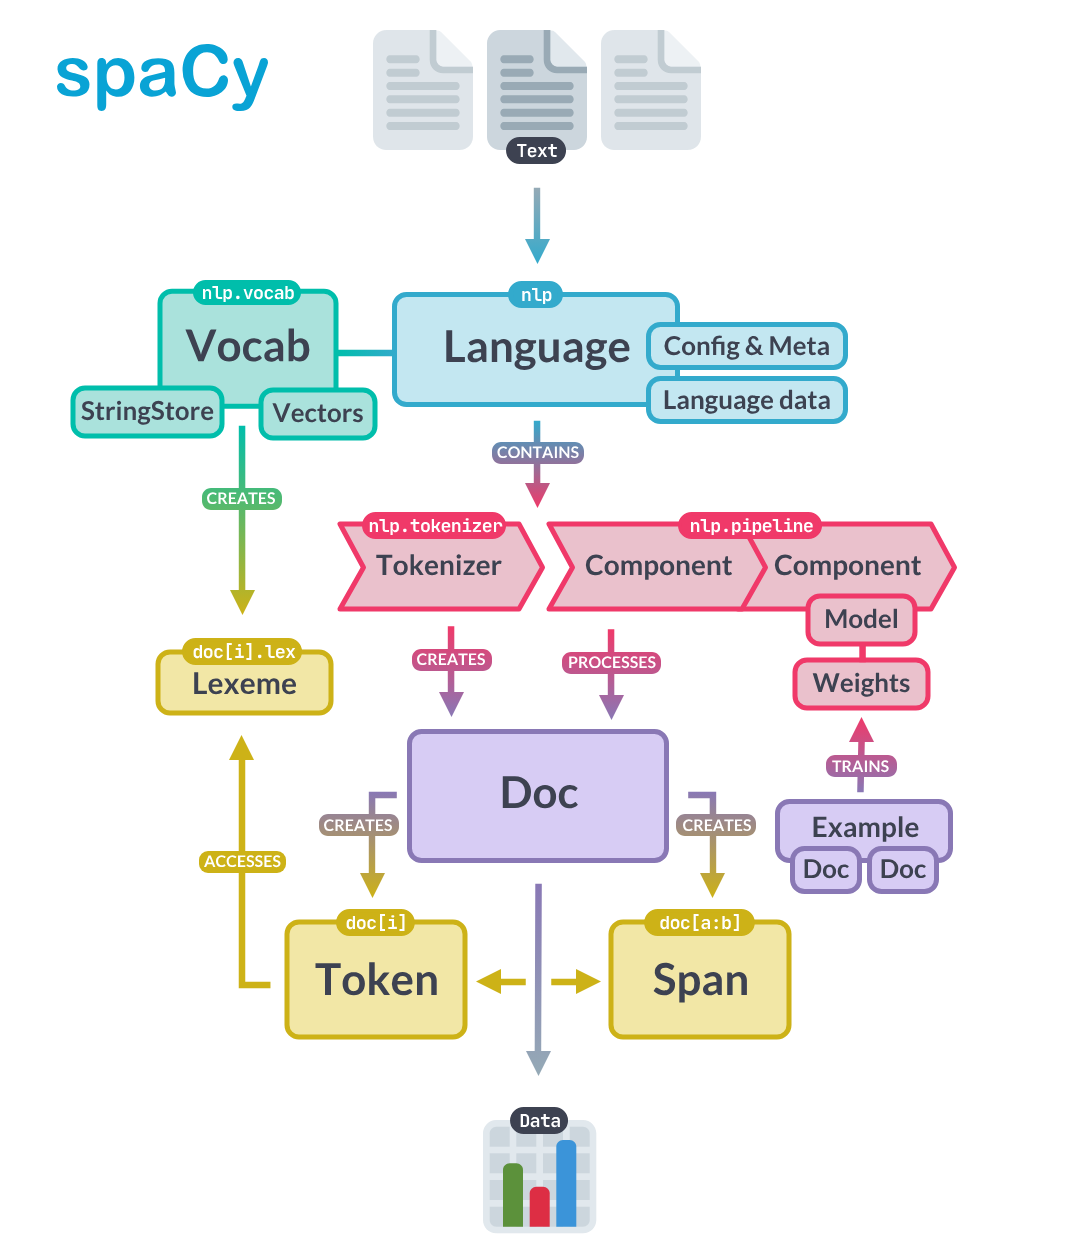

In [1]:
# $ pip install spacy

import spacy

# download statistical models
# $ python -m spacy download en_core_web_sm

# Check that your installed models are up to date
# $ python -m spacy validate

# Load the installed model "en_core_web_sm"
nlp = spacy.load("en_core_web_sm")

AttributeError: module 'lib' has no attribute 'OpenSSL_add_all_algorithms'

In [ ]:
# Processing text with the nlp object returns a Doc object that holds all information about the tokens, 
# their linguistic features and their relationships.
doc = nlp("This is a text")

# Token texts
[token.text for token in doc]

# accessing spans - Span indices are exclusive. 
doc[2: 7]

# creating custom span
from spacy.tokens import Span
doc = nlp("I live in New York")
span = Span(doc, 3, 5, label="GPE")  # Span for "New York" with label GPE (geopolitical)
span.text

In [ ]:
# doc.sents is a generator that yields sentence spans
doc1 = nlp("This a sentence. This is another one.")
[sent.text for sent in doc1.sents]

In [ ]:
# Coarse-grained part-of-speech tags
[token.pos_ for token in doc]

# Fine-grained part-of-speech tags
[token.tag_ for token in doc]

In [ ]:
### Syntactic dependencies (predicted by statistical model)

# Dependency labels
[token.dep_ for token in doc]

# Syntactic head token (governor)
[token.head.text for token in doc]

In [ ]:
### named entity (predicted by statistical model)

# Text and label of named entity span
[(ent.text, ent.label_) for ent in doc.ents]

In [ ]:
### base noun phrases - needs the tagger and parser

# doc.noun_chunks is a generator that yields spans
[chunk.text for chunk in doc.noun_chunks]

In [ ]:
### label explanation
spacy.explain("RB")
# >> 'adverb'

spacy.explain("GPE")
# >> 'Countries, cities, states'

In [ ]:
### visualization

from spacy import displacy
doc = nlp("This is a sentence")
displacy.render(doc, style="dep")  # visualizes dependencies
displacy.render(doc, style="ent") # visualizes named entities

In [ ]:
### word vectors and similarities
# To use word vectors, you need to install the larger models ending in md or lg , 
# for example en_core_web_lg

doc1 = nlp("I like cats")
doc2 = nlp("I like dogs")

doc1.similarity(doc2)  # Compare 2 documents
doc1[2].similarity(doc2[2])  # Compare 2 tokens
doc1[0].similarity(doc2[1:3])  # Compare tokens and spans

In [ ]:
# Vector as a numpy array
doc = nlp("I like cats")

# The L2 norm of the token's vector
doc[2].vector
doc[2].vector_norm

In [ ]:
### pipeline information that contains certain built in components

nlp = spacy.load("en_core_web_sm")
nlp.pipe_names
# ['tagger', 'parser', 'ner']
nlp.pipeline
# [('tagger', <spacy.pipeline.Tagger>),
# ('parser', <spacy.pipeline.DependencyParser>),
# ('ner', <spacy.pipeline.EntityRecognizer>)]

In [ ]:
### Components can be added first, last (default), or before or after an existing component.

from spacy.language import Language

@Language.component("custom_component")
def custom_component(doc): 
    #Function that modifies the doc and returns it 
    #Do something to the doc herereturn doc nlp.add_pipe(custom_component, first=True) 
    #Add the component first in the pipeline

In [ ]:
### Custom attributes that are registered on the global Doc, Token and Span classes and become available as ._.

from spacy.tokens import Doc, Token, Span
doc = nlp("The sky over New York is blue")

Token.set_extension("is_color", default=False)  # Register custom attribute on Token class
doc[6]._.is_color = True  # Overwrite extension attribute with default value

In [ ]:
### property extensions with getters and setters

# Register custom attribute on Doc class
get_reversed = lambda doc: doc.text[::-1]
Doc.set_extension("reversed", getter=get_reversed)

# Compute value of extension attribute with getter
doc._.reversed
# >> 'eulb si kroY weN revo yks ehT'

In [ ]:
### rule based matching

# Matcher is initialized with the shared vocab
from spacy.matcher import Matcher

# Each dict represents one token and its attributes
matcher = Matcher(nlp.vocab)

# Add with ID, optional callback and pattern(s)
pattern = [{"LOWER": "new"}, {"LOWER": "york"}]
matcher.add('CITIES', [pattern])

# Match by calling the matcher on a Doc object
doc = nlp("I live in New York")
matches = matcher(doc)
print(matches)

# Matches are (match_id, start, end) tuples
for match_id, start, end in matches:
    # Get the matched span by slicing the Doc
    span = doc[start:end]
    print(span.text)
# 'New York'

In [ ]:
### token patterns

# "love cats", "loving cats", "loved cats"
pattern1 = [{"LEMMA": "love"}, {"LOWER": "cats"}]
# "10 people", "twenty people"
pattern2 = [{"LIKE_NUM": True}, {"TEXT": "people"}]
# "book", "a cat", "the sea" (noun + optional article)
pattern3 = [{"POS": "DET", "OP": "?"}, {"POS": "NOUN"}]